In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [28]:
df = pd.read_csv("./Healthcare_Dataset_Preprocessed.csv")

In [29]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,0,1,1,0,0
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,0,0,1,0,0
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,1,0,0,0,0
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,1,0,0,1,0
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,0,1,0,1,0


In [30]:
len(df), df.count()

(9549,
 Age                     9549
 BMI                     9549
 Blood_Pressure          9549
 Cholesterol             9549
 Glucose_Level           9549
 Heart_Rate              9549
 Sleep_Hours             9549
 Exercise_Hours          9549
 Water_Intake            9549
 Stress_Level            9549
 Target                  9549
 Smoking                 9549
 Alcohol                 9549
 Diet                    9549
 MentalHealth            9549
 PhysicalActivity        9549
 MedicalHistory          9549
 Allergies               9549
 Diet_Type_Vegan         9549
 Diet_Type_Vegetarian    9549
 Blood_Group_AB          9549
 Blood_Group_B           9549
 Blood_Group_O           9549
 dtype: int64)

In [31]:
df.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
count,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,...,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000
mean,33.806786,25.660697,130.382658,199.091528,100.225678,73.613782,6.951409,1.892345,3.580899,4.382134,...,1.005864,0.998429,1.003351,1.004713,0.989318,0.329354,0.335742,0.244947,0.253849,0.252592
std,24.566473,1.942369,27.878476,1.969234,2.157999,1.681538,2.352152,1.378714,1.622874,2.078593,...,0.815877,0.821844,0.808800,0.813506,0.815699,0.470003,0.472274,0.430078,0.435235,0.434522
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,-0.000000,-0.000000,-0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,24.000000,113.000000,198.000000,99.000000,73.000000,5.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,26.000000,134.000000,199.000000,100.000000,74.000000,7.000000,2.000000,4.000000,4.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,50.000000,27.000000,150.000000,200.000000,102.000000,75.000000,9.000000,3.000000,5.000000,6.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,14.000000,8.000000,10.000000,12.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Checking for multi-collinearity

In [32]:
corr = df.corr()
corr

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
Age,1.000000,0.184184,0.135372,0.437928,-0.291863,-0.029772,0.055429,-0.126124,-0.216521,-0.112340,...,0.004838,0.018068,0.001018,0.000281,-0.012093,-0.006525,-0.008175,-0.016337,-0.014327,0.023705
BMI,0.184184,1.000000,-0.184409,0.133500,-0.164456,0.173756,0.095744,-0.101090,0.028345,0.133988,...,0.008658,-0.002827,0.000591,-0.004754,-0.021326,-0.000791,-0.008814,-0.008196,-0.002296,0.016430
Blood_Pressure,0.135372,-0.184409,1.000000,0.223215,0.213538,0.028363,0.214011,0.033026,0.088576,-0.168972,...,-0.010694,0.013662,-0.011846,0.003546,0.002782,-0.025206,0.007877,0.006900,0.008540,-0.008775
Cholesterol,0.437928,0.133500,0.223215,1.000000,-0.222827,0.094366,0.089054,0.077927,-0.339838,-0.229260,...,0.003838,-0.005800,0.003556,0.007184,-0.014388,-0.019108,0.010874,-0.000010,-0.011959,0.001253
Glucose_Level,-0.291863,-0.164456,0.213538,-0.222827,1.000000,0.222710,-0.012943,0.085329,-0.030768,0.523401,...,-0.004975,-0.009544,0.008808,-0.009793,0.007438,-0.002660,0.000357,0.009946,0.019509,-0.012212
Heart_Rate,-0.029772,0.173756,0.028363,0.094366,0.222710,1.000000,0.096408,-0.127714,0.117684,0.250096,...,0.010354,0.001910,0.002492,-0.000430,-0.008582,-0.009984,-0.010654,-0.002409,0.026216,-0.026438
Sleep_Hours,0.055429,0.095744,0.214011,0.089054,-0.012943,0.096408,1.000000,0.081452,0.220526,-0.658623,...,0.004897,0.001532,0.000801,-0.010006,-0.018503,-0.015649,0.008182,-0.011217,0.003968,-0.012481
Exercise_Hours,-0.126124,-0.101090,0.033026,0.077927,0.085329,-0.127714,0.081452,1.000000,-0.149500,-0.128686,...,0.007265,-0.022610,-0.017898,0.005308,-0.005027,-0.015908,0.007583,0.011800,-0.002975,-0.004779
Water_Intake,-0.216521,0.028345,0.088576,-0.339838,-0.030768,0.117684,0.220526,-0.149500,1.000000,-0.317456,...,0.004546,-0.005990,-0.001324,0.003162,-0.000455,-0.009876,-0.004285,0.012196,0.002951,-0.010118
Stress_Level,-0.112340,0.133988,-0.168972,-0.229260,0.523401,0.250096,-0.658623,-0.128686,-0.317456,1.000000,...,0.005348,-0.000691,0.005157,-0.004162,0.008708,0.011813,-0.008762,-0.006304,0.021499,0.004208


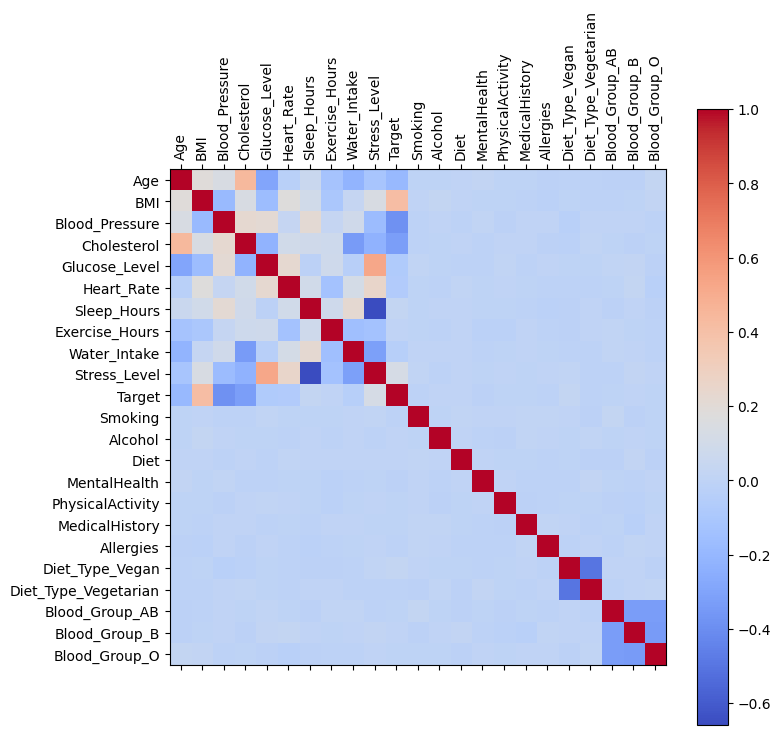

In [33]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 8))
cax = ax.matshow(corr, cmap='coolwarm')
fig.colorbar(cax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
plt.show()

In [34]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [35]:
#function to calculate the VIF score
def calculate_vif(data):
    """Calculate VIF for a dataframe."""
    vif_data = pd.DataFrame()
    vif_data["Variable"] = data.columns
    vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_data

vif_data = calculate_vif(X)

In [36]:
vif_data.sort_values("VIF", ascending=False)

,Variable,VIF
3,Cholesterol,9848.029725
4,Glucose_Level,5916.160519
5,Heart_Rate,2961.864774
1,BMI,297.977104
9,Stress_Level,45.919789
6,Sleep_Hours,40.791088
2,Blood_Pressure,27.911540
8,Water_Intake,11.419974
0,Age,4.122777
7,Exercise_Hours,3.361836


### We can see that VIF is high for some features, indicating correlation, so dropping them

In [37]:
X = X.drop(["Cholesterol", "Glucose_Level", "Heart_Rate", "Stress_Level", "Blood_Pressure"], axis=1)

In [38]:
calculate_vif(X)

,Variable,VIF
0,Age,3.272604
1,BMI,30.828509
2,Sleep_Hours,10.589081
3,Exercise_Hours,2.993343
4,Water_Intake,6.736289
5,Smoking,2.463780
6,Alcohol,2.478620
7,Diet,2.508090
8,MentalHealth,2.459303
9,PhysicalActivity,2.521054


### We still have few features with high VIF value, but those looks important for now, so keeping them

## Model Building

In [49]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [50]:
model = LogisticRegression()
model.fit(X, y)

c:\Users\RuchitaMotwani\.virtualenvs\Foundational_ML_Algorithams-RKBdPIqP\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [53]:
y_pred = model.predict(x_test)

In [56]:
accuracy_score(y_test, y_pred)

0.7392670157068063

In [57]:
f1_score(y_test, y_pred)

0.7596525096525096